# Diabetes Prediction - Data Analysis
This notebook explores the Pima Indians Diabetes dataset step by step. It is an **educational project, not a medical diagnosis**.

## 1. Import libraries and load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../dataset/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 2. Shape, missing values, duplicates

In [2]:
print('Shape:', df.shape)
print('Missing values:\n', df.isnull().sum())
print('Duplicate rows:', df.duplicated().sum())

Shape: (768, 9)
Missing values:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Duplicate rows: 0


## 3. Basic statistics
Look at the **min** column: Glucose, BloodPressure, BMI and others have a minimum of 0, which is impossible for a living person. These zeros really mean *not measured*.

In [3]:
df.describe().round(2)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


## 4. Impossible zeros

In [4]:
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(df[cols] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

We replace those zeros with `NaN` and later fill them with the **median** (learned from the training data only).

In [5]:
df[cols] = df[cols].replace(0, np.nan)
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

## 5. Target balance
`Outcome`: 0 = no diabetes, 1 = diabetes.

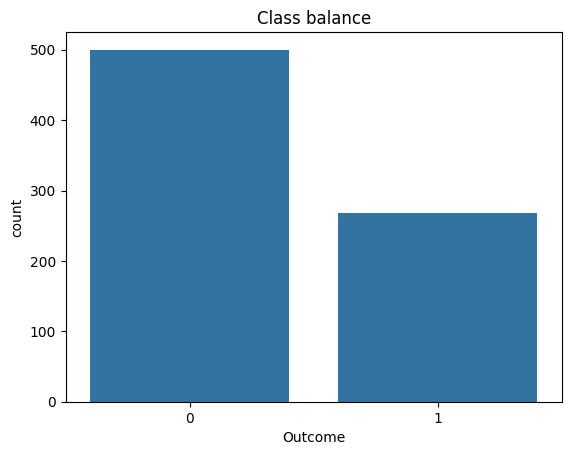

Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

In [6]:
sns.countplot(x='Outcome', data=df)
plt.title('Class balance')
plt.show()
df['Outcome'].value_counts(normalize=True).round(3)

## 6. Distributions by outcome

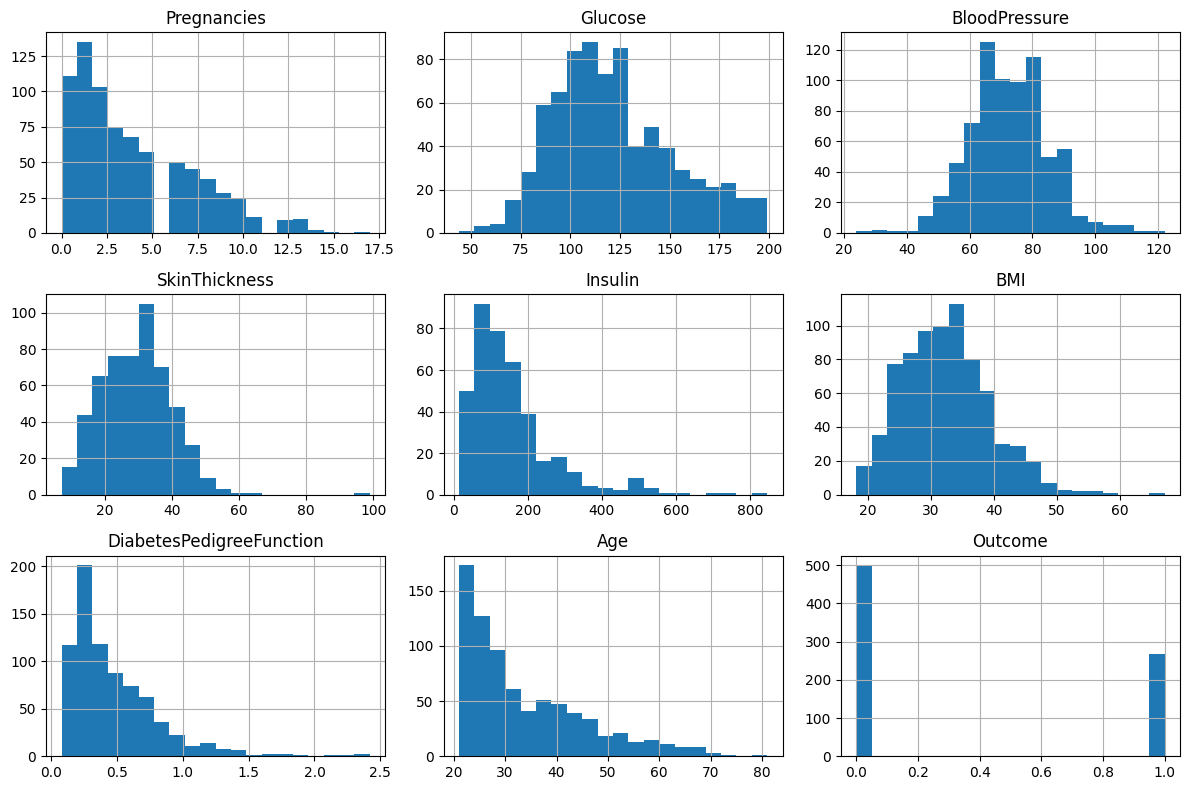

In [7]:
df.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

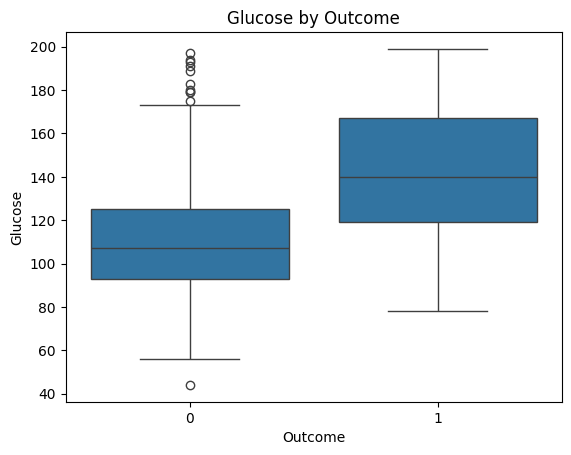

In [8]:
sns.boxplot(x='Outcome', y='Glucose', data=df)
plt.title('Glucose by Outcome')
plt.show()

## 7. Correlation heatmap
Glucose, BMI and Age show the strongest link with the outcome.

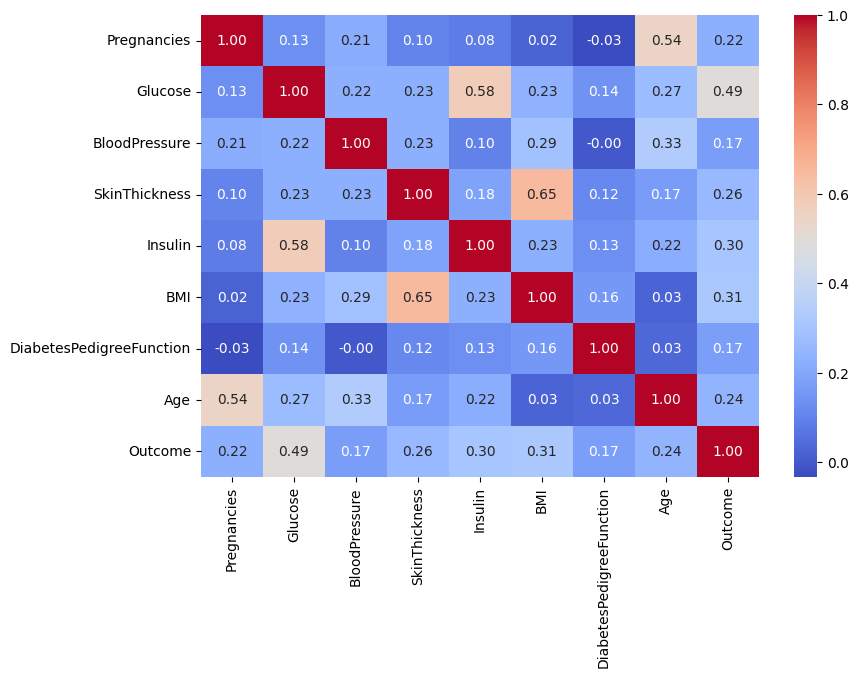

In [9]:
plt.figure(figsize=(9, 6))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

## 8. Train and compare models
Same steps as `train_model.py`.

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X = df.drop('Outcome', axis=1)
y = df['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_train_s = scaler.fit_transform(imputer.fit_transform(X_train))
X_test_s = scaler.transform(imputer.transform(X_test))

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42),
}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    print('=====', name, '=====')
    print(confusion_matrix(y_test, pred))
    print(classification_report(y_test, pred, target_names=['No Diabetes', 'Diabetes']))

===== Logistic Regression =====
[[75 25]
 [16 38]]
              precision    recall  f1-score   support

 No Diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154



===== Random Forest =====
[[74 26]
 [13 41]]
              precision    recall  f1-score   support

 No Diabetes       0.85      0.74      0.79       100
    Diabetes       0.61      0.76      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.73       154
weighted avg       0.77      0.75      0.75       154



## 9. Feature importance (Random Forest)

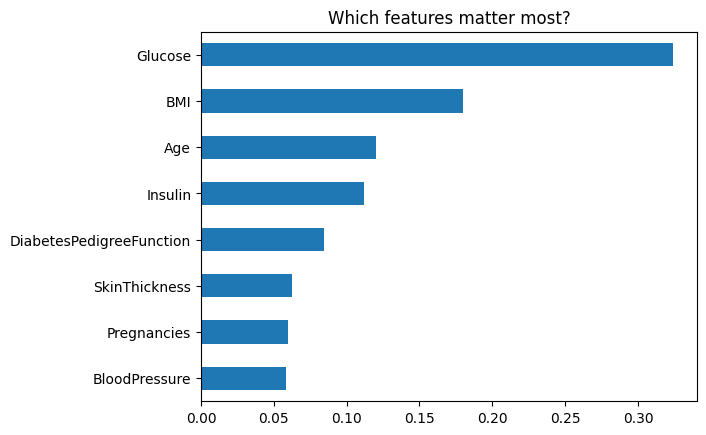

In [11]:
rf = models['Random Forest']
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
imp.plot(kind='barh', title='Which features matter most?')
plt.show()